# Analisi di `transactions_simple_delta_train.csv`

Dataset sintetico generato dall'esperimento **`simple_delta`**: i quattro
cluster sono **identici in tutto** — distribuzione di `importo`, pool di
`merchant`/`cocau`, volume di transazioni, *e* ora-del-giorno / giorno-settimana
(uniformi, non informativi) — e differiscono **solo** nel **rate** λ dei gap
esponenziali tra transazioni consecutive.

| Cluster | gap_lambda | gap medio |
|---|---|---|
| `veloce` | 0.5 | ~2 giorni |
| `medio` | 0.1429 | ~7 giorni |
| `lento` | 0.05 | ~20 giorni |
| `lentissimo` | 0.02 | ~50 giorni |

È il duale di `simple_timing`, ma sul canale che il modello **consuma**
davvero: il `delta_t` che alimenta `TimeAwarePositionalEncoding`. L'analisi è
quindi:
1. **controllo** — importo / merchant / cocau / ora / giorno-settimana devono
   risultare indistinguibili tra cluster;
2. **segnale** — la distribuzione del gap separa i cluster; lo verifichiamo
   proiettando con **PCA** e **t-SNE** feature di gap aggregate per cliente, e
   mostrando il contrasto con le feature di valore.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 60)

In [2]:
def find_repo_root(start):
    """Risale le cartelle finche' trova la radice del repo (data/ + config.toml)."""
    for p in [start, *start.parents]:
        if (p / 'data').is_dir() and (p / 'config.toml').exists():
            return p
    return start

ROOT = find_repo_root(Path.cwd())
CSV = ROOT / 'data' / 'transactions_simple_delta_train.csv'

# Nomi colonna canonici (src/constant.py -> DataConfig)
CLIENT, CLUSTER, TS = 'client_id', 'cluster', 'timestamp'
AMOUNT, MERCHANT, COCAU = 'importo', 'merchant', 'cocau'

df = pd.read_csv(CSV)
df[TS] = pd.to_datetime(df[TS], unit='s')
df = df.sort_values([CLIENT, TS]).reset_index(drop=True)
df['hour'] = df[TS].dt.hour
df['dow'] = df[TS].dt.dayofweek  # 0 = lunedi
df['gap_days'] = df.groupby(CLIENT)[TS].diff().dt.total_seconds() / 86400.0
print('File:', CSV)
print('Righe x colonne:', df.shape)
df.head()

File: /home/julien/Documents/python-proj/embeddingclient/data/transactions_simple_delta_train.csv
Righe x colonne: (480477, 9)


,client_id,cluster,timestamp,importo,merchant,cocau,hour,dow,gap_days
0,0,medio,2022-02-05 10:20:18,25.640530,Aldi,27,10,5,NaN
1,0,medio,2022-02-06 22:19:13,38.733538,Esselunga,149,22,6,1.499248
2,0,medio,2022-02-18 03:17:00,42.655260,Aldi,89,3,4,11.206794
3,0,medio,2022-02-18 07:50:16,85.655401,Lidl,8,7,4,0.189769
4,0,medio,2022-02-26 10:09:32,8.380298,Aldi,120,10,5,8.096713


## 0. Panoramica e bilanciamento dei cluster

In [3]:
df.info()
print('\nValori mancanti per colonna:')
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 480477 entries, 0 to 480476
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype        
---  ------     --------------   -----        
 0   client_id  480477 non-null  int64        
 1   cluster    480477 non-null  str          
 2   timestamp  480477 non-null  datetime64[s]
 3   importo    480477 non-null  float64      
 4   merchant   480477 non-null  str          
 5   cocau      480477 non-null  int64        
 6   hour       480477 non-null  int32        
 7   dow        480477 non-null  int32        
 8   gap_days   476477 non-null  float64      
dtypes: datetime64[s](1), float64(2), int32(2), int64(2), str(2)
memory usage: 29.3 MB

Valori mancanti per colonna:
client_id       0
cluster         0
timestamp       0
importo         0
merchant        0
cocau           0
hour            0
dow             0
gap_days     4000
dtype: int64


,n_clients,n_transactions,tx_per_client
cluster,,,
veloce,1000,119244,119.2
medio,1000,120315,120.3
lento,1000,119777,119.8
lentissimo,1000,121141,121.1


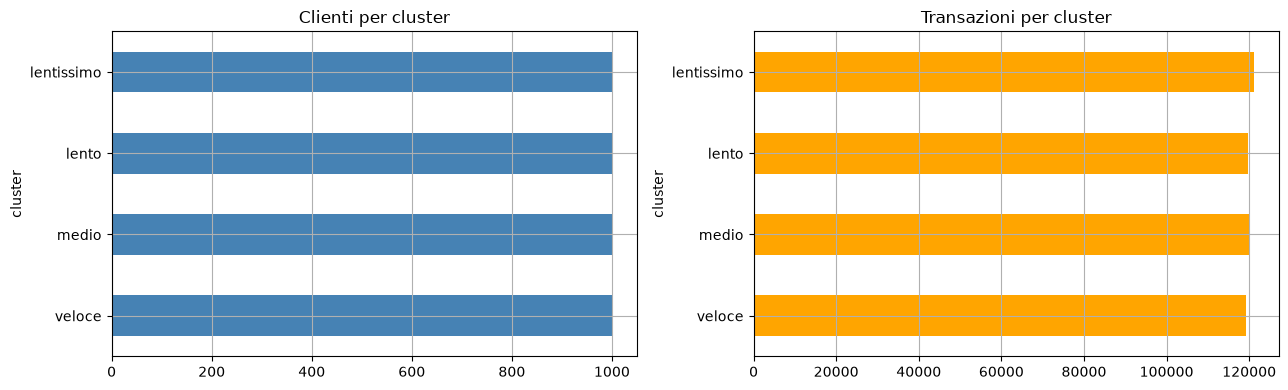

In [4]:
# ordine dal piu' veloce al piu' lento
clusters = [c for c in ['veloce', 'medio', 'lento', 'lentissimo'] if c in set(df[CLUSTER])]
n_clients = df.groupby(CLUSTER)[CLIENT].nunique()
n_tx = df[CLUSTER].value_counts()
summary = pd.DataFrame({'n_clients': n_clients, 'n_transactions': n_tx}).loc[clusters]
summary['tx_per_client'] = (summary['n_transactions'] / summary['n_clients']).round(1)
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
n_clients.loc[clusters].plot.barh(ax=ax[0], color='steelblue', title='Clienti per cluster')
n_tx.loc[clusters].plot.barh(ax=ax[1], color='orange', title='Transazioni per cluster')
plt.tight_layout()

## 1. Controllo: tutto tranne il gap è condiviso

Importo, merchant, cocau provengono da un unico profilo; ora-del-giorno e
giorno-settimana sono uniformi. Ci aspettiamo distribuzioni **sovrapposte**.

Statistiche di importo per cluster (attese ~uguali):


,mean,std,median
cluster,,,
veloce,41.88,28.80,41.94
medio,41.86,28.79,41.83
lento,41.84,28.82,41.80
lentissimo,41.71,28.86,41.65


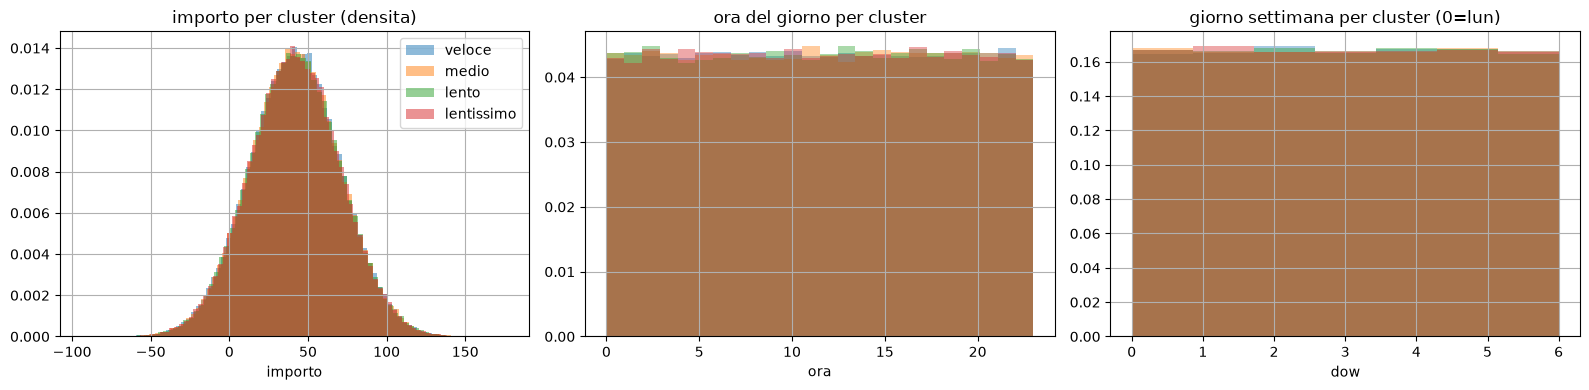

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c in clusters:
    ax[0].hist(df.loc[df[CLUSTER] == c, AMOUNT], bins=80, alpha=0.5, density=True, label=c)
ax[0].set(title='importo per cluster (densita)', xlabel='importo')
ax[0].legend()
for c in clusters:
    ax[1].hist(df.loc[df[CLUSTER] == c, 'hour'], bins=24, alpha=0.4, density=True, label=c)
ax[1].set(title='ora del giorno per cluster', xlabel='ora')
for c in clusters:
    ax[2].hist(df.loc[df[CLUSTER] == c, 'dow'], bins=7, alpha=0.4, density=True, label=c)
ax[2].set(title='giorno settimana per cluster (0=lun)', xlabel='dow')
plt.tight_layout()

print('Statistiche di importo per cluster (attese ~uguali):')
df.groupby(CLUSTER)[AMOUNT].agg(['mean', 'std', 'median']).loc[clusters].round(2)

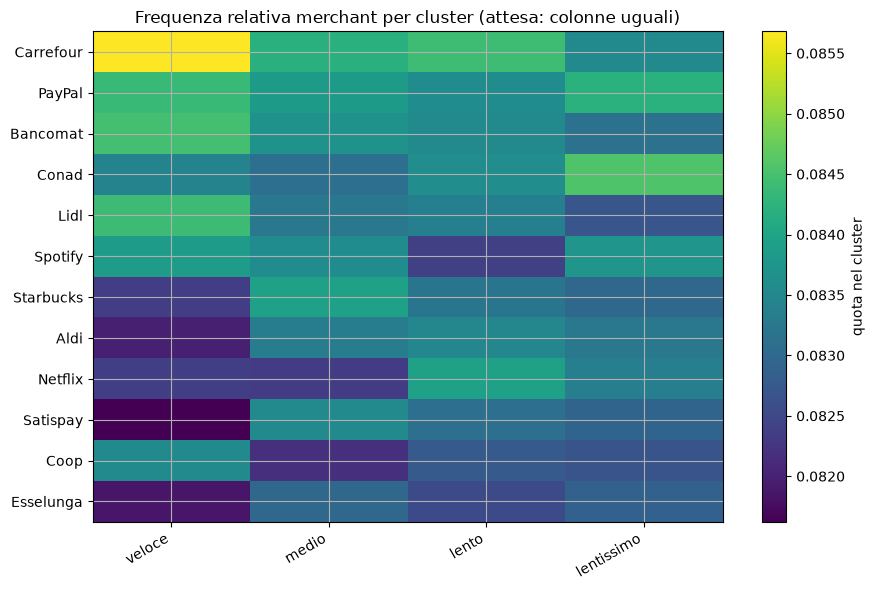

In [6]:
# Frequenza relativa dei merchant per cluster: colonne ~identiche => nessun segnale
top = df[MERCHANT].value_counts().head(12).index
ct = pd.crosstab(df[MERCHANT], df[CLUSTER], normalize='columns').loc[top, clusters]
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(ct.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=30, ha='right')
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index)
ax.set_title('Frequenza relativa merchant per cluster (attesa: colonne uguali)')
fig.colorbar(im, ax=ax, label='quota nel cluster')
plt.tight_layout()

## 2. Il segnale: il gap tra transazioni (`delta_t`)

Qui i cluster si separano nettamente: il gap è esponenziale con rate λ
specifico, quindi cambia la scala media e la coda della distribuzione.

,mean,median,std
cluster,,,
veloce,2.00,1.38,2.00
medio,6.99,4.87,6.97
lento,19.96,13.87,19.95
lentissimo,49.81,34.40,49.91


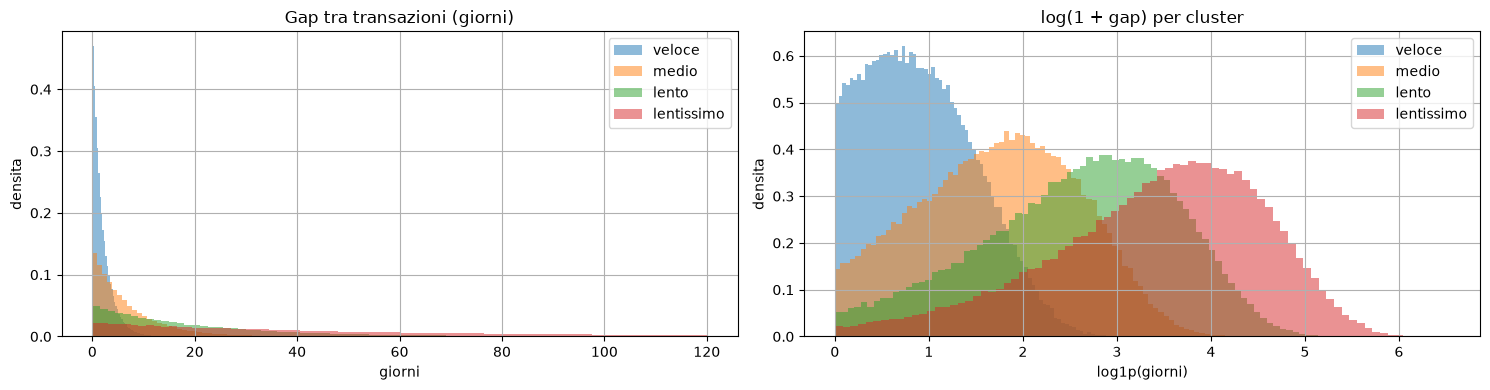

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
for c in clusters:
    gap = df.loc[df[CLUSTER] == c, 'gap_days'].dropna()
    ax[0].hist(gap[gap < 120], bins=80, alpha=0.5, density=True, label=c)
ax[0].set(title='Gap tra transazioni (giorni)', xlabel='giorni', ylabel='densita')
ax[0].legend()
for c in clusters:
    gap = df.loc[df[CLUSTER] == c, 'gap_days'].dropna()
    ax[1].hist(np.log1p(gap), bins=80, alpha=0.5, density=True, label=c)
ax[1].set(title='log(1 + gap) per cluster', xlabel='log1p(giorni)', ylabel='densita')
ax[1].legend()
plt.tight_layout()

df.groupby(CLUSTER)['gap_days'].agg(['mean', 'median', 'std']).loc[clusters].round(2)

## 3. Proiezione su feature di gap per cliente

Riassumiamo ogni cliente con statistiche e quantili del proprio gap, piu'
l'istogramma normalizzato dei gap su scala logaritmica. Dopo standardizzazione
proiettiamo con PCA e t-SNE: i quattro cluster devono ordinarsi/separarsi per
velocita'.

In [8]:
g = df.groupby(CLIENT)
gap_feats = g['gap_days'].agg(['mean', 'std', 'median', 'min', 'max']).fillna(0.0)
for q in (0.1, 0.25, 0.5, 0.75, 0.9):
    gap_feats['q' + str(int(q * 100))] = g['gap_days'].quantile(q)

# Istogramma normalizzato su bin di log(1 + gap)
df['lg'] = np.log1p(df['gap_days'].fillna(0.0))
bins = np.linspace(0.0, float(df['lg'].max()), 11)
df['lg_bin'] = np.clip(np.digitize(df['lg'], bins), 0, len(bins))
lg_hist = pd.crosstab(df[CLIENT], df['lg_bin'])
lg_hist = lg_hist.div(lg_hist.sum(axis=1), axis=0).add_prefix('lg')

feats = gap_feats.join(lg_hist).fillna(0.0)
labels = g[CLUSTER].first().loc[feats.index]
print('Matrice feature di gap per cliente:', feats.shape)
feats.head()

Matrice feature di gap per cliente: (4000, 21)


,mean,std,median,min,max,q10,q25,q50,q75,q90,lg1,lg2,lg3,lg4,lg5,lg6,lg7,lg8,lg9,lg10,lg11
client_id,,,,,,,,,,,,,,,,,,,,,
0,6.629022,6.533333,4.679931,0.025718,31.201366,0.341951,1.501586,4.679931,9.940845,14.993285,0.161538,0.200000,0.230769,0.261538,0.130769,0.015385,0.000000,0.000000,0.0,0.0,0.0
1,7.557383,7.047593,5.689352,0.060208,36.338194,0.779830,2.498979,5.689352,10.382170,16.729061,0.151079,0.151079,0.237410,0.258993,0.179856,0.021583,0.000000,0.000000,0.0,0.0,0.0
2,7.172611,7.575692,4.473981,0.150799,31.835891,0.795384,2.029444,4.473981,9.120718,18.039671,0.127660,0.223404,0.244681,0.234043,0.106383,0.063830,0.000000,0.000000,0.0,0.0,0.0
3,19.416846,19.624688,15.934317,0.027072,127.692292,2.553315,5.103461,15.934317,25.009711,39.402315,0.064103,0.051282,0.205128,0.128205,0.307692,0.179487,0.051282,0.012821,0.0,0.0,0.0
4,19.221193,17.657975,13.062269,0.073218,88.049583,2.760683,6.526788,13.062269,25.506331,45.507368,0.051471,0.058824,0.125000,0.235294,0.279412,0.176471,0.073529,0.000000,0.0,0.0,0.0


Varianza spiegata cumulata: [0.684 0.797 0.845 0.892 0.925 0.952 0.965 0.974 0.981 0.986]


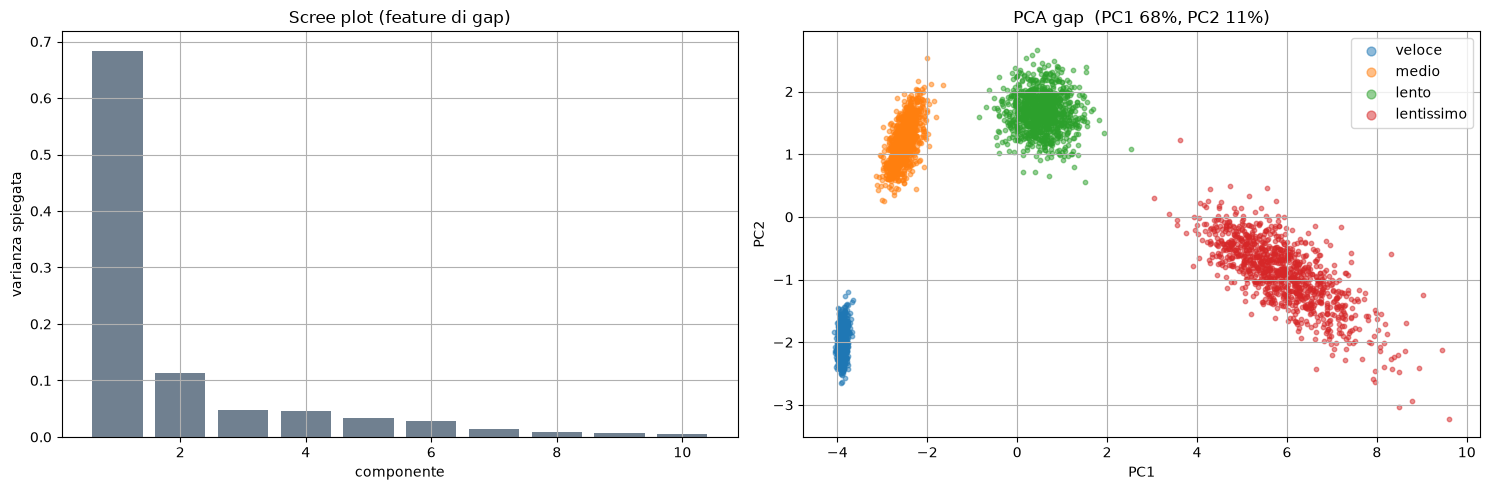

In [9]:
X = StandardScaler().fit_transform(feats.values)
pca = PCA(n_components=10, random_state=0).fit(X)
Xp = pca.transform(X)
evr = pca.explained_variance_ratio_
print('Varianza spiegata cumulata:', np.round(np.cumsum(evr), 3))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar(range(1, len(evr) + 1), evr, color='slategray')
ax[0].set(title='Scree plot (feature di gap)', xlabel='componente', ylabel='varianza spiegata')
for c in clusters:
    m = labels.values == c
    ax[1].scatter(Xp[m, 0], Xp[m, 1], s=10, alpha=0.5, label=c)
ax[1].set(title=f'PCA gap  (PC1 {evr[0]:.0%}, PC2 {evr[1]:.0%})', xlabel='PC1', ylabel='PC2')
ax[1].legend(markerscale=2)
plt.tight_layout()

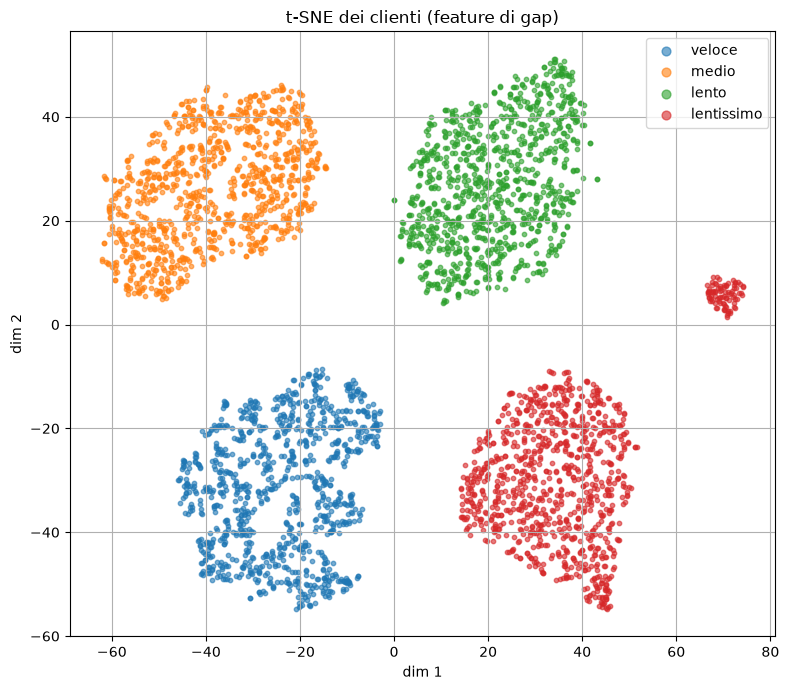

In [10]:
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=0)
Xe = tsne.fit_transform(X)
fig, ax = plt.subplots(figsize=(8, 7))
for c in clusters:
    m = labels.values == c
    ax.scatter(Xe[m, 0], Xe[m, 1], s=10, alpha=0.6, label=c)
ax.set(title='t-SNE dei clienti (feature di gap)', xlabel='dim 1', ylabel='dim 2')
ax.legend(markerscale=2)
plt.tight_layout()

## 4. Contrasto: feature di valore vs di gap

La PCA sulle sole feature di **valore** (importo + istogrammi merchant/cocau),
condivise tra cluster, **non** dovrebbe separare le classi — confermando che
l'unico segnale è il gap temporale.

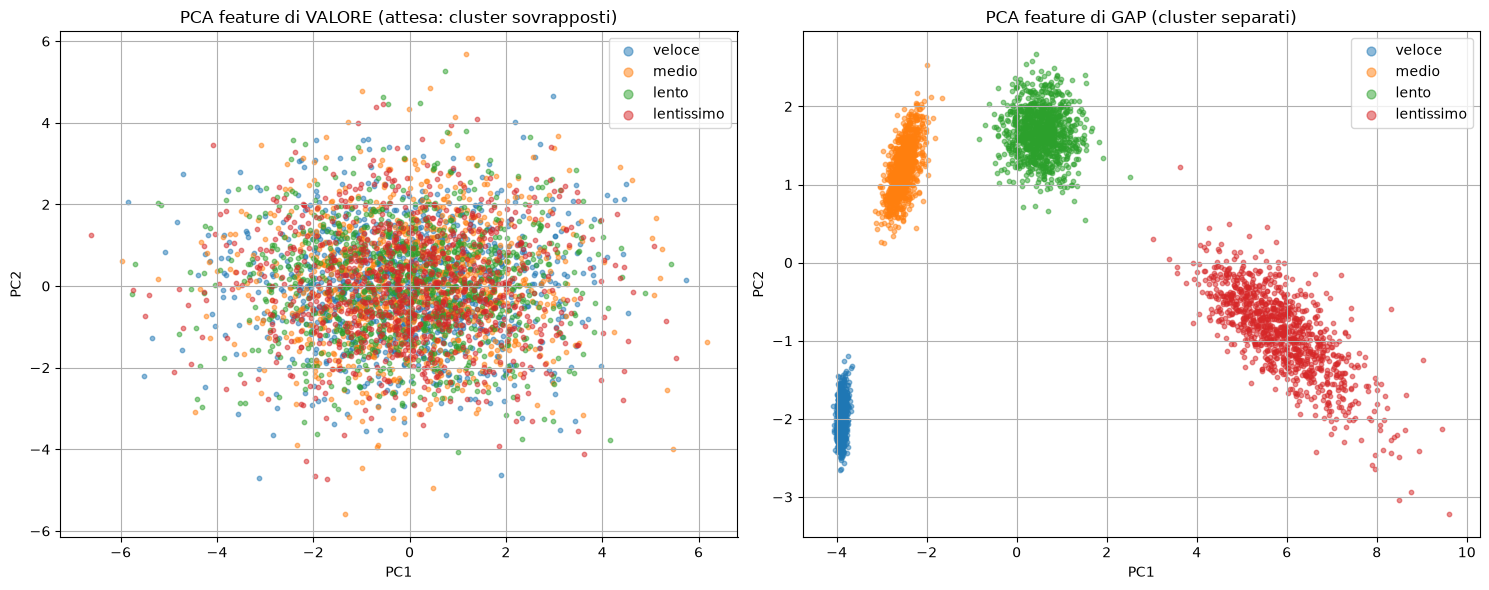

In [11]:
num_feats = pd.DataFrame({
    'amount_mean': g[AMOUNT].mean(),
    'amount_std': g[AMOUNT].std().fillna(0.0),
    'abs_amount_mean': g[AMOUNT].apply(lambda s: s.abs().mean()),
    'frac_negative': g[AMOUNT].apply(lambda s: (s < 0).mean()),
    'n_unique_merchant': g[MERCHANT].nunique(),
    'n_unique_cocau': g[COCAU].nunique(),
})
TOPM = df[MERCHANT].value_counts().head(15).index
TOPC = df[COCAU].value_counts().head(15).index
mh = pd.crosstab(df[CLIENT], df[MERCHANT])[TOPM]
mh = mh.div(mh.sum(axis=1).replace(0, 1), axis=0).add_prefix('m_')
ch = pd.crosstab(df[CLIENT], df[COCAU])[TOPC]
ch = ch.div(ch.sum(axis=1).replace(0, 1), axis=0).add_prefix('c_')
feats_val = num_feats.join(mh).join(ch).fillna(0.0).loc[feats.index]

Xv = StandardScaler().fit_transform(feats_val.values)
Xpv = PCA(n_components=2, random_state=0).fit_transform(Xv)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for c in clusters:
    m = labels.values == c
    ax[0].scatter(Xpv[m, 0], Xpv[m, 1], s=10, alpha=0.5, label=c)
    ax[1].scatter(Xp[m, 0], Xp[m, 1], s=10, alpha=0.5, label=c)
ax[0].set(title='PCA feature di VALORE (attesa: cluster sovrapposti)', xlabel='PC1', ylabel='PC2')
ax[1].set(title='PCA feature di GAP (cluster separati)', xlabel='PC1', ylabel='PC2')
ax[0].legend(markerscale=2)
ax[1].legend(markerscale=2)
plt.tight_layout()

## 5. Conclusioni

* Importo, merchant, cocau, ora-del-giorno e giorno-settimana sono
  **indistinguibili** tra cluster: la PCA sulle sole feature di valore mescola
  le classi — il controllo voluto dall'esperimento.
* La distribuzione del **gap** (`delta_t`) cambia in scala e coda secondo λ:
  le feature di gap separano nettamente i quattro cluster (PC1 cattura quasi
  tutta la varianza, ordinando da `veloce` a `lentissimo`).
* A differenza di `simple_timing`, questo segnale vive proprio nel canale
  `delta_t` che il modello consuma via `TimeAwarePositionalEncoding`: è quindi
  un probe **positivo** — l'architettura attuale dovrebbe recuperare i cluster.